# ERA V5 Session 12 — 32 Virtual GPU ZeRO Simulation

Educational simulator — not physical GPU benchmarks.

## 02. Assignment objective

Compare baseline DP, ZeRO-1/2/3 on **32 virtual GPUs** with explicit memory, communication, and compute accounting.

## 03. Conceptual model

Each rank is a `VirtualGPU` object with ownership sets for parameters, gradients, and optimizer state.

## 04. Configuration

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
for candidate in (ROOT, ROOT.parent):
    if (candidate / 'src').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt

from src.config import SimConfig, WORLD_SIZE, GPUS_PER_NODE, NUM_NODES
from src.virtual_gpu import make_cluster
from src.model import DemoModel
from src.memory import MemoryAccounting
from src.simulation import run_strategy
from src.experiments import run_all_experiments, scaling_sweep, save_records
from src.visualization import generate_all_plots

cfg = SimConfig()
print('WORLD_SIZE', WORLD_SIZE, 'nodes', NUM_NODES, 'gpus/node', GPUS_PER_NODE)
print('Simulation assumption bandwidth (Gbps):', cfg.intra_node_bandwidth_gbps, cfg.inter_node_bandwidth_gbps)

WORLD_SIZE 32 nodes 4 gpus/node 8
Simulation assumption bandwidth (Gbps): 300.0 25.0


## 05. Create 32 virtual GPUs

In [2]:
gpus = make_cluster(cfg)
assert len(gpus) == 32
for g in gpus[:4]:
    print(f'rank={g.rank} node={g.node_id}')

rank=0 node=0
rank=1 node=0
rank=2 node=0
rank=3 node=0


## 06. Demo model

In [3]:
model = DemoModel.build(cfg)
print('logical_parameter_count', model.logical_parameter_count)

logical_parameter_count 1000000


## 07. Memory model

In [4]:
from src.virtual_gpu import assign_replicated
assign_replicated(gpus, cfg.parameter_count)
mem = MemoryAccounting(cfg, gpus[0])
bd = mem.breakdown()
print('parameter_memory', bd.parameters)
print('optimizer_memory (Adam m+v FP32)', bd.optimizer)
print('peak', bd.peak)

parameter_memory 2000000
optimizer_memory (Adam m+v FP32) 8000000
peak 16016384


## 08. Baseline Data Parallel

In [5]:
m_base = run_strategy('baseline_dp', cfg)
print(m_base)

StepMetrics(strategy='baseline_dp', peak_memory_per_gpu=16078884, aggregate_memory=514524288, compute_work=624000000.0, communication_bytes=4000000, communication_time=0.0006399999999999999, compute_time=0.624, total_step_time=0.62464, communication_fraction=0.0010245901639344263, idle_fraction=0.0010245901639344263, memory_breakdown={'parameters': 2000000, 'gradients': 2000000, 'optimizer': 8000000, 'activations': 16384, 'buffers': 62500, 'temporary': 0})


**OBSERVATION:**

On the default 1M-parameter run, baseline `peak_memory_per_gpu` is **16,078,884** bytes and every rank’s ownership map is the full parameter range (`assign_replicated`). `communication_bytes` for the gradient all-reduce is **4,000,000**.

**QUESTION:** Why does every GPU consume approximately the same model-state memory?

### My answer

I initially assumed more GPUs would automatically mean less memory per GPU. The run showed the opposite for model state: each rank still holds the full parameter, gradient, and Adam tensors, so peak memory is essentially the same on every GPU (~16 MB here). Data parallelism splits the **batch**, not the **weights**. The sanity check `count_replication_factor(..., 'param_element_ids') == 32` matches that story — replication factor 32, not 1/32.

## 09. ZeRO-1

In [6]:
m_z1 = run_strategy('zero1', cfg)
print(m_z1)

StepMetrics(strategy='zero1', peak_memory_per_gpu=8328884, aggregate_memory=266524288, compute_work=624000000.0, communication_bytes=4000000, communication_time=0.0006399999999999999, compute_time=0.624, total_step_time=0.62464, communication_fraction=0.0010245901639344263, idle_fraction=0.0010245901639344263, memory_breakdown={'parameters': 2000000, 'gradients': 2000000, 'optimizer': 250000, 'activations': 16384, 'buffers': 62500, 'temporary': 0})


**OBSERVATION:**

ZeRO-1 drops `peak_memory_per_gpu` to **8,328,884** bytes versus baseline **16,078,884**. Gradient all-reduce volume is unchanged at **4,000,000** bytes. On rank 0 the optimizer slice in the breakdown shrinks because `optimizer_element_ids` is only one shard.

**QUESTION:** Which memory component stopped being fully replicated? Why?

### My answer

What became clear from the ownership map is that only **optimizer state** (Adam m and v in FP32) is sharded in ZeRO-1. Parameters and gradients are still full on every GPU, which is why we still pay for an all-reduce on the full gradient tensor. The memory win is mostly the optimizer footprint: each rank stores roughly 1/32 of the Adam state instead of the whole thing.

## 10. ZeRO-2

In [7]:
m_z2 = run_strategy('zero2', cfg)
print(m_z2)

StepMetrics(strategy='zero2', peak_memory_per_gpu=6391384, aggregate_memory=204524288, compute_work=624000000.0, communication_bytes=2000000, communication_time=0.00031999995999999997, compute_time=0.624, total_step_time=0.62431999996, communication_fraction=0.0005125575987001894, idle_fraction=0.0005125575987001894, memory_breakdown={'parameters': 2000000, 'gradients': 62500, 'optimizer': 250000, 'activations': 16384, 'buffers': 62500, 'temporary': 0})


**OBSERVATION:**

ZeRO-2 peak memory is **6,391,384** bytes. Communication switches to reduce-scatter with **2,000,000** bytes logged for the step (versus **4,000,000** all-reduce at baseline). `grad_element_ids` and `optimizer_element_ids` are partitioned per rank; `param_element_ids` stays full.

**QUESTION:** Why does sharding gradients save memory but not remove parameter replication?

### My answer

ZeRO-2 keeps a full parameter replica on each GPU because forward and backward still need the whole weight tensor locally in this simulator. What changes is the **gradient**: after backward we reduce-scatter so each rank keeps only its gradient shard, and optimizer state stays sharded like ZeRO-1. Parameters never went on a shard map, so parameter memory did not drop — only gradients and optimizer did.

## 11. ZeRO-3

In [8]:
m_z3 = run_strategy('zero3', cfg)
print(m_z3)

StepMetrics(strategy='zero3', peak_memory_per_gpu=2578884, aggregate_memory=18524288, compute_work=624000000.0, communication_bytes=6000000, communication_time=0.000383999952, compute_time=0.624, total_step_time=0.624383999952, communication_fraction=0.0006150060732330109, idle_fraction=0.0006150060732330109, memory_breakdown={'parameters': 62500, 'gradients': 62500, 'optimizer': 250000, 'activations': 16384, 'buffers': 62500, 'temporary': 2000000})


**OBSERVATION:**

ZeRO-3 aggregate `memory_per_gpu` is only **578,884** bytes steady-state, but `peak_memory_per_gpu` is **2,578,884** bytes when the temporary full parameter view is counted. `communication_bytes` is **6,000,000**, above baseline **4,000,000**. The step performs all-gather before compute, reduce-scatter on gradients, and all-gather again on parameters (`zero3.py`).

**QUESTION:** Why does memory decrease further? Where did additional communication come from?

### My answer

Steady-state memory falls because parameters, gradients, and optimizer are all sharded — each rank’s `param_element_ids` covers 1/32 of the elements. The extra communication is the price of not storing full weights: we all-gather to build a full parameter view for forward/backward, then reduce-scatter gradients, then all-gather updated shards. Peak memory spikes above steady state because `temp_full_param_elements` models the gathered view; that is not the same as the quiet shard footprint.

## 12. Communication simulation

In [9]:
from src.communication import all_reduce, reduce_scatter, all_gather
ranks = list(range(32))
b = cfg.parameter_count * cfg.bytes_per_param_train
for op in [all_reduce(cfg, ranks, b), reduce_scatter(cfg, ranks, b), all_gather(cfg, ranks, b//32)]:
    print(op.operation, op.bytes_moved, op.label())

all_reduce 4000000 Simulation assumption — not measured NVIDIA performance
reduce_scatter 2000000 Simulation assumption — not measured NVIDIA performance
all_gather 2000000 Simulation assumption — not measured NVIDIA performance


## 13. Compute simulation

In [10]:
from src.compute import step_compute, simulated_time_from_work
cw = step_compute(model, cfg)
print('compute_work', cw.total_work)
print('simulated_compute_time', simulated_time_from_work(cw.total_work, cfg))

compute_work 624000000.0
simulated_compute_time 0.624


## 14. Communication/compute overlap (conceptual)

In [11]:
from src.communication import overlap_adjusted_time
t_comm = m_z3.communication_time
t_comp = m_z3.compute_time
print('overlap-adjusted comm time', overlap_adjusted_time(t_comm, t_comp, cfg.bucket_size_bytes, b, cfg.overlap_fraction))

overlap-adjusted comm time 0.0001535999808


## 15. Experiment matrix

In [12]:
records = run_all_experiments(cfg)
scaling = scaling_sweep(cfg)
out = Path('outputs/experiment_matrix.json')
save_records(records + scaling, out)
print('saved', out, 'rows', len(records)+len(scaling))

saved outputs/experiment_matrix.json rows 17


## 16. Results

In [13]:
import pandas as pd
df = pd.DataFrame([r.__dict__ for r in records])
df[['experiment_id','strategy','peak_memory_per_gpu','communication_bytes','total_step_time','communication_fraction']]

,experiment_id,strategy,peak_memory_per_gpu,communication_bytes,total_step_time,communication_fraction
0,exp1_baseline_dp,baseline_dp,16078884,4000000,0.624640,0.001025
1,exp2_zero1,zero1,8328884,4000000,0.624640,0.001025
2,exp3_zero2,zero2,6391384,2000000,0.624320,0.000513
3,exp4_zero3,zero3,2578884,6000000,0.624384,0.000615
4,exp5_single_node_zero3,zero3,2578884,6000000,0.624154,0.000247
5,exp6_multi_node_zero3,zero3,2578884,6000000,0.624384,0.000615
6,exp7_bucket_large,zero3,2578884,6000000,0.624384,0.000615
7,exp7_bucket_small,zero3,2578884,6000000,0.624384,0.000615
8,exp8_small,zero3,1297634,3000000,0.312378,0.001210
9,exp8_medium,zero3,5141384,12000000,1.248396,0.000317


## 17. Plots

In [14]:
fig_dir = Path('outputs/figures')
generate_all_plots(records + scaling, fig_dir)
list(fig_dir.glob('*.png'))

[PosixPath('outputs/figures/comm_fraction_model_sweep.png'),
 PosixPath('outputs/figures/communication_volume.png'),
 PosixPath('outputs/figures/overlap_timeline.png'),
 PosixPath('outputs/figures/compute_vs_comm.png'),
 PosixPath('outputs/figures/scaling_baseline.png'),
 PosixPath('outputs/figures/bucket_size_effect.png'),
 PosixPath('outputs/figures/memory_breakdown.png'),
 PosixPath('outputs/figures/peak_memory_per_gpu.png')]

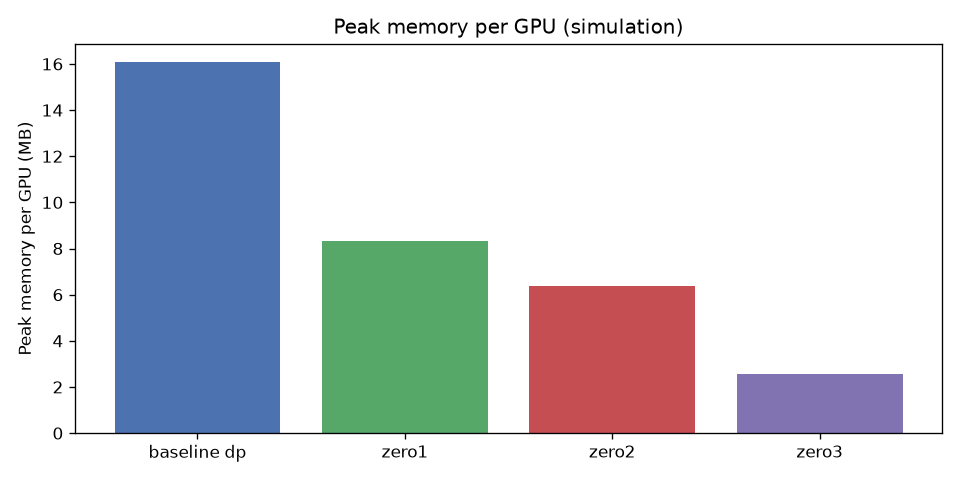

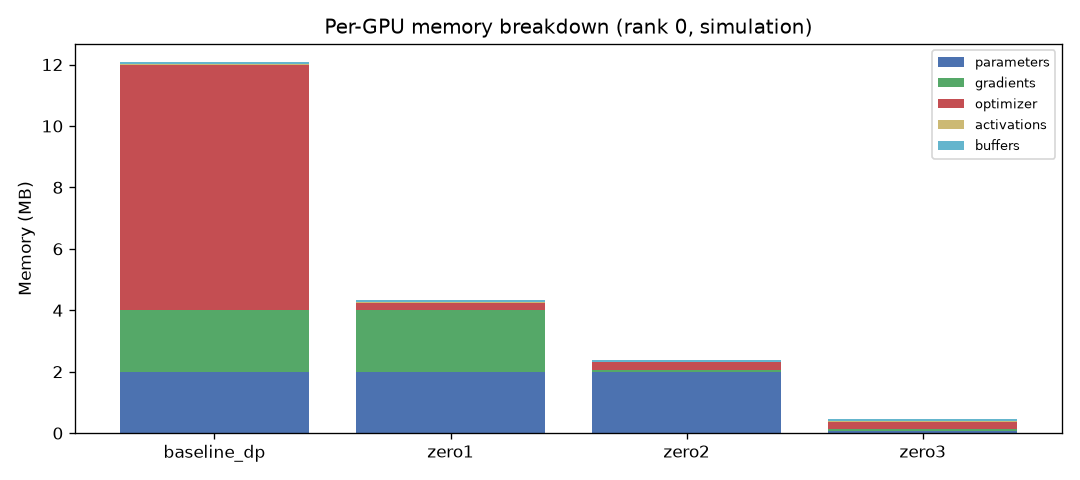

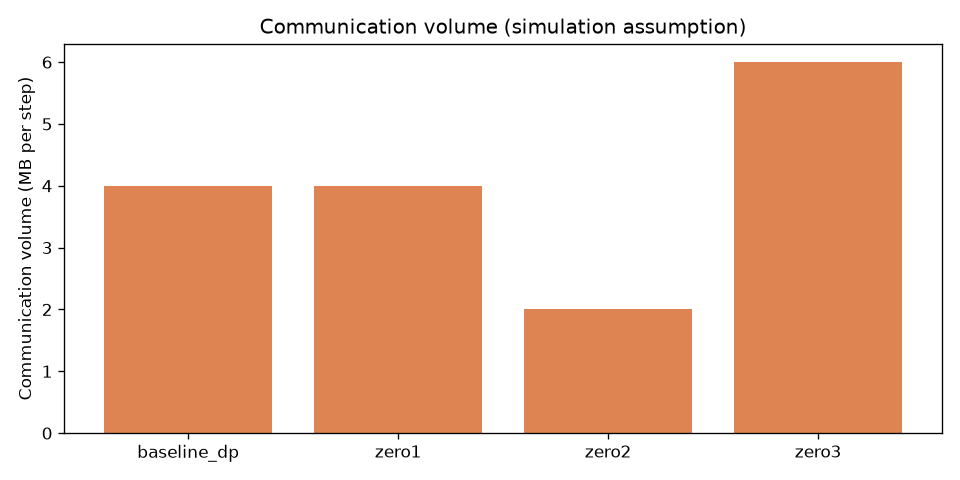

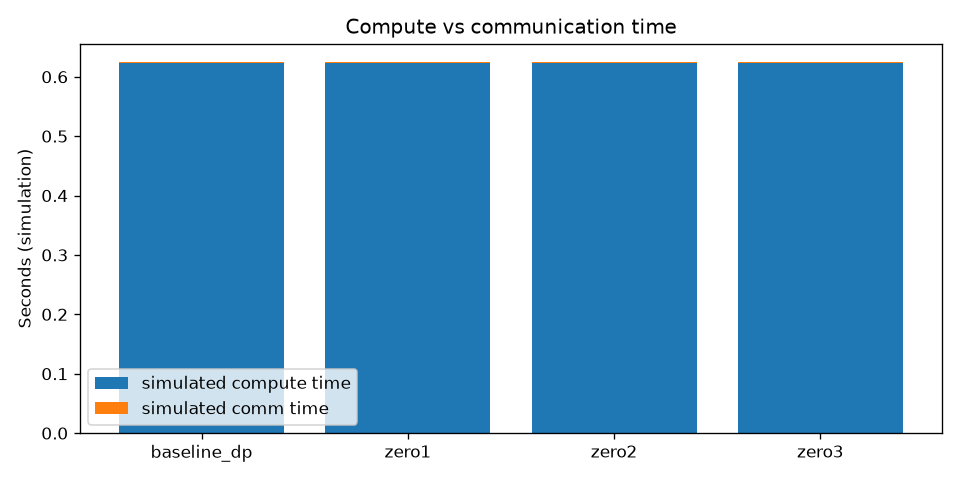

In [15]:
from IPython.display import Image, display
for name in ['peak_memory_per_gpu.png','memory_breakdown.png','communication_volume.png','compute_vs_comm.png']:
    display(Image(filename=fig_dir / name))

## 18. Sanity checks

In [16]:
from src.virtual_gpu import (
    assign_replicated, assign_zero1_optimizer_shard, assign_zero2_grad_opt_shard,
    assign_zero3_full_shard, count_replication_factor, sum_shard_coverage, make_cluster,
)
total = cfg.parameter_count
gpus = make_cluster(cfg)
assign_replicated(gpus, total)
assert count_replication_factor(gpus, 'param_element_ids', total) == 32
assign_zero1_optimizer_shard(gpus, total, 32)
assert count_replication_factor(gpus, 'optimizer_element_ids', total) == 1
assign_zero2_grad_opt_shard(gpus, total, 32)
assert count_replication_factor(gpus, 'grad_element_ids', total) == 1
assign_zero3_full_shard(gpus, total, 32)
assert sum_shard_coverage(gpus, 'param_element_ids', total) == total
print('sanity checks passed')

sanity checks passed


## 19. Concept → Evidence

| Concept | Evidence in this notebook |
|--------|---------------------------|
| Data Parallelism | `m_base` peak memory |
| All-reduce | baseline `communication_bytes` |
| ZeRO-1 | optimizer shard ownership |
| ZeRO-2 | reduce-scatter + grad shards |
| ZeRO-3 | all-gather + param shards |
| Overlap | bucket experiment rows + overlap cell |

# What I Understood

The through-line for me is **ownership**: baseline DP replicates everything; each ZeRO stage shards one more tensor class until ZeRO-3 shards params, grads, and optimizer. Memory accounting follows those sets literally — not a single “16 bytes per param” guess. Communication is whatever collectives the strategy calls, with bytes and simulated time coming from `communication.py`, not from CUDA timers. See the seven-question table below and the final reflection for the trade-off story.

## Seven core questions (concept → this lab)

**1. Why doesn't normal data parallelism reduce model-state memory per GPU?**  
Because each rank still stores full weights, full gradients, and full optimizer state (`assign_replicated`). In my run, peak memory stayed ~16 MB per GPU from world size 1 through 32 on baseline — only aggregate cluster memory grows.

**2. What exactly does ZeRO-1 shard?**  
Only `optimizer_element_ids` — Adam m/v per parameter element. Params and grads stay replicated; all-reduce size stayed 4,000,000 bytes.

**3. What does ZeRO-2 add?**  
Gradient sharding via reduce-scatter: `grad_element_ids` is partitioned. Params are still full replicas; comm dropped to 2,000,000 bytes in the log.

**4. Why does ZeRO-3 require all-gather?**  
Forward/backward need a full parameter view, but steady storage is a shard. `zero3.py` all-gathers shards before compute and again after the optimizer step.

**5. Why does ZeRO-3 require reduce-scatter?**  
Gradients are sharded too — after backward we reduce-scatter the full gradient tensor so each rank keeps only its shard for the local optimizer update.

**6. Why can lower memory mean higher communication?**  
My ZeRO-3 step logged 6,000,000 communication bytes vs 4,000,000 for baseline: more collectives to move shards into a usable full view, then scatter results back.

**7. What is the overall memory vs communication trade-off?**  
ZeRO-3 cut steady per-GPU model-state memory to ~0.55 MB (aggregate accounting) but raised bytes moved and introduced a higher **peak** (~2.58 MB) during gathers. You buy headroom with sharding; you pay in collective traffic and transient buffers — still only a simulation, not a GPU benchmark.

## Reflection questions (summary)

**OBSERVATION:**

Multi-node ZeRO-3 (`exp6`) reports `communication_time` **0.000384** s vs single-node assumption (`exp5`) **0.000154** s for the same **6,000,000** bytes. Baseline scaling: `total_step_time` goes from **0.624** s at world size 1 to **0.62464** s at 32 while `peak_memory_per_gpu` stays ~16 MB.

**QUESTION:** Why can adding GPUs fail to provide proportional speedup?

### My answer

Compute work per step did not shrink when I added GPUs — the simulator still charges each rank the same `compute_work`. What changed is communication time and idle fraction (comm while waiting on slower inter-node links in exp6). So I get more aggregate batch parallelism in principle, but not a proportionally shorter step if comm or replication overhead dominates; here comm is small versus compute, so the curve is nearly flat.

## 22. Final observations

All metrics above come from `outputs/experiment_matrix.json` produced in-section (default `SimConfig`, 1M parameters, 32 ranks). Re-run `python scripts/run_all.py` after changing code or config.

## 23. Reproducibility

```bash
cd session12
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
python scripts/run_all.py
```

## Interactive summary tables

In [17]:
summary = pd.DataFrame([
    {'strategy': m.strategy, 'peak_memory': m.peak_memory_per_gpu, 'comm_bytes': m.communication_bytes,
     'compute_t': m.compute_time, 'total_t': m.total_step_time}
    for m in [m_base, m_z1, m_z2, m_z3]
])
summary

,strategy,peak_memory,comm_bytes,compute_t,total_t
0,baseline_dp,16078884,4000000,0.624,0.624640
1,zero1,8328884,4000000,0.624,0.624640
2,zero2,6391384,2000000,0.624,0.624320
3,zero3,2578884,6000000,0.624,0.624384


| Question | Evidence | My explanation |
|----------|----------|----------------|
| Why does ZeRO-1 save memory? | Peak 8,328,884 vs 16,078,884 bytes | Optimizer state is sharded; params/grads still full. |
| Why does ZeRO-2 save more? | Peak 6,391,384 bytes | Gradients shard too; reduce-scatter replaces full grad replication. |
| Why does ZeRO-3 save more again? | Steady ~578,884 B/GPU aggregate slice | Params shard at rest; only gather windows need full tensors. |
| Why does communication increase? | 6,000,000 vs 4,000,000 bytes | Extra all-gather + reduce-scatter sequence in `zero3.py`. |
| Why does multi-node matter? | exp5 vs exp6 comm time | Same bytes, higher simulated time when inter-node bandwidth applies. |
| Why does bucket size matter? | `overlap_adjusted_time` + exp7 | Smaller buckets expose more overlap opportunities in the conceptual model; comm bytes unchanged. |
| Why doesn't more GPU always speed up? | scaling_ws* `total_step_time` | Per-rank compute unchanged; comm and replication do not vanish. |

## My Understanding — Final Reflection

Building this lab forced me to stop thinking of ZeRO as a single “memory trick” and instead track **who owns each element** on each of the 32 virtual GPUs. Baseline DP made the redundancy obvious: every rank’s map covered all one million parameter elements, so peak memory barely moved when I scaled world size — only the cluster-wide total ballooned. ZeRO-1 chipped away at Adam state, ZeRO-2 added gradient shards and a reduce-scatter, and ZeRO-3 finally shard parameters — each stage changed the ownership sets and the collectives in `strategies/`, and the experiment JSON lined up with that (peak memory stepped down, ZeRO-3 comm bytes stepped up).

The part that clicked late was **steady vs peak** on ZeRO-3: ~0.55 MB steady per GPU in the aggregate accounting versus ~2.58 MB peak when `temp_full_param_elements` models the all-gather window. That is the trade-off in one line — you do not get shard-sized memory and zero communication at the same time.

I am treating all timings and bandwidths here as **simulation assumptions** from `communication.py`. They helped me reason about idle time and topology (exp5 vs exp6), but I would not present them as measured GPU performance — the value is the traceable chain from sharding rules to bytes moved to my interpretation.